In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('D:/HII/OneDrive/HydroDataSci/Project/เกณฑ์ฝน จ.สงขลา/Data')
OUTPUT_DIR = Path('D:/HII/rainfall_threshold_songkla/output')

# Data Loading

In [2]:
df_raw = pd.read_csv(
DATA_DIR / '20260410_Rainfall-สงขลา.csv',
    encoding='utf-8-sig',
    parse_dates=['rainfall_datetime'],
    dtype={'tele_station_oldcode': str}
)

In [3]:
df_r1h = pd.read_csv(
    DATA_DIR / '20260410_Rainfall1h-สงขลา.csv',
    encoding='utf-8-sig',
    parse_dates=['rainfall_datetime'],
    dtype={'tele_station_oldcode': str}
)

In [4]:
df_meta1 = pd.read_csv(
    DATA_DIR / 'm_tele_station_20220324.csv',
    encoding='utf-8-sig',
)

In [5]:
df_meta2 = pd.read_csv(
    DATA_DIR / 'm_tele_station_20260507.csv',
    encoding='utf-8-sig',
)

# General detail

In [6]:
df_raw.head()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
0,48568,สงขลา,2019-02-14 13:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
1,48568,สงขลา,2019-02-14 16:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
2,48568,สงขลา,2019-02-14 19:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
3,48568,สงขลา,2019-02-14 22:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
4,48568,สงขลา,2019-02-15 01:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD


In [7]:
df_r1h.head()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall1h,tumbon_name,amphoe_name,province_name
0,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 09:00:00,0.2,เขาแดง,สะบ้าย้อย,สงขลา
1,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 10:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
2,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 11:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
3,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 12:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
4,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 13:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา


In [8]:
df_meta1.head()

,id,subbasin_id,agency_id,geocode_id,tele_station_name_th,tele_station_name_en,tele_station_lat,tele_station_long,tele_station_oldcode,tele_station_type,...,critical_level_m,critical_level_msl,reference_id,subbasin_id_22,basin_id_22,subbasin_id_25,basin_id_25,river_gid,river_distant,adjust_geocode_id
0,1032662,106.0,12.0,1950.0,Rain เธเธธเธ•เธฐเนเธ,NaN,14.433429,101.87185,M_RAIN,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3538,148.0,8.0,2715.0,เธญ.เธ•เธฃเธฐเธเธฒเธฃเธเธทเธเธเธฅ,Trakan Phuet Phon,15.614920,105.01614,PMTS11,A,...,NaN,NaN,NaN,148.0,5.0,105.0,5.0,141708.0,0.007901,NaN
2,501187,234.0,3.0,6171.0,เธเนเธฒเธเธเนเธณเธเธงเธ,NaN,17.438261,100.67500,STN1149,R,...,NaN,NaN,NaN,234.0,9.0,161.0,9.0,82979.0,0.001031,NaN
3,651,209.0,9.0,6107.0,เธเธฅเธญเธเธเธฑเธเธเนเธณเธขเธก-เธเนเธฒ...,NaN,17.366200,99.84370,DIN001,A,...,NaN,NaN,NaN,209.0,8.0,147.0,8.0,84208.0,0.000043,NaN
4,1849,325.0,3.0,7313.0,เธเนเธฒเธเธชเธณเธเธฑเธเน€เธเธตเธขเธ,NaN,8.934702,99.70000,STN0066,R,...,NaN,NaN,NaN,325.0,22.0,220.0,21.0,216917.0,0.000739,NaN


In [9]:
df_meta2.head()

,tele_station_oldcode,tele_station_name,tele_station_lat,tele_station_long,tumbon_name,amphoe_name,province_name,agency_shortname,tele_station_type,tmd_area_name,basin_name,subbasin_name
0,0000,องค์การบริหารส่วนตำบลห้วยผา,19.426110,97.998340,หมอกจำแป่,เมืองแม่ฮ่องสอน,แม่ฮ่องสอน,DISASTER,R,ภาคเหนือ,สาละวิน,น้ำแม่ปายตอนล่างส่วนที่ 2
1,48300,แม่ฮ่องสอน,19.298972,97.975778,จองคำ,เมืองแม่ฮ่องสอน,แม่ฮ่องสอน,TMD,R,ภาคเหนือ,สาละวิน,น้ำแม่ปายตอนล่างส่วนที่ 2
2,48302,ดอยอ่างขาง,19.931389,99.048333,ม่อนปิ่น,ฝาง,เชียงใหม่,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่ฝาง
3,48303,เชียงราย,19.961389,99.881389,บ้านดู่,เมืองเชียงราย,เชียงราย,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่กกตอนล่างส่วนที่ 3
4,48304,เชียงราย สกษ.,19.870833,99.782778,ป่าอ้อดอนชัย,เมืองเชียงราย,เชียงราย,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่กกตอนล่างส่วนที่ 2


In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8037169 entries, 0 to 8037168
Data columns (total 13 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tele_station_oldcode  str           
 1   station_name_th       str           
 2   rainfall_datetime     datetime64[us]
 3   rainfall10m           float64       
 4   rainfall5m            float64       
 5   rainfall30m           float64       
 6   rainfall1h            float64       
 7   rainfall3h            float64       
 8   tumbon_name           str           
 9   amphoe_name           str           
 10  province_name         str           
 11  tmd_area_name         str           
 12  agency                str           
dtypes: datetime64[us](1), float64(5), str(7)
memory usage: 797.1 MB


In [11]:
df_r1h.info()

<class 'pandas.DataFrame'>
RangeIndex: 889283 entries, 0 to 889282
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tele_station_oldcode  889283 non-null  str           
 1   station_name_th       889283 non-null  str           
 2   rainfall_datetime     889283 non-null  datetime64[us]
 3   rainfall1h            889283 non-null  float64       
 4   tumbon_name           889283 non-null  str           
 5   amphoe_name           889283 non-null  str           
 6   province_name         889283 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 47.5 MB


In [12]:
df_meta1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     6499 non-null   int64  
 1   subbasin_id            6475 non-null   float64
 2   agency_id              6492 non-null   float64
 3   geocode_id             6061 non-null   float64
 4   tele_station_name_th   6027 non-null   str    
 5   tele_station_name_en   2277 non-null   str    
 6   tele_station_lat       6379 non-null   float64
 7   tele_station_long      6374 non-null   float64
 8   tele_station_oldcode   6493 non-null   str    
 9   tele_station_type      5065 non-null   str    
 10  left_bank              1316 non-null   float64
 11  right_bank             1319 non-null   float64
 12  ground_level           1211 non-null   float64
 13  water_storage_station  0 non-null      float64
 14  max_waterlevel_20y     0 non-null      float64
 15  sort_order     

In [13]:
df_meta2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5722 entries, 0 to 5721
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tele_station_oldcode  5722 non-null   str    
 1   tele_station_name     5721 non-null   str    
 2   tele_station_lat      5722 non-null   float64
 3   tele_station_long     5722 non-null   float64
 4   tumbon_name           5705 non-null   str    
 5   amphoe_name           5707 non-null   str    
 6   province_name         5710 non-null   str    
 7   agency_shortname      5722 non-null   str    
 8   tele_station_type     5721 non-null   str    
 9   tmd_area_name         5710 non-null   str    
 10  basin_name            5718 non-null   str    
 11  subbasin_name         5718 non-null   str    
dtypes: float64(2), str(10)
memory usage: 536.6 KB


# Data Cleaning 

clean 'df'

In [14]:
rain_cols = ['rainfall10m', 'rainfall5m', 'rainfall30m', 'rainfall1h', 'rainfall3h']

df_no_sentinel = df_raw.replace(999999.0, np.nan)

phantom_rows = df_no_sentinel.loc[:, rain_cols].isna().all(axis=1)

df = df_no_sentinel[~phantom_rows]

df

print(f'Total number of phantom rows dropped: {phantom_rows.sum()} ({round(phantom_rows.sum()/len(df) * 100, 2)}%)')
print(f'Number of stations (raw): {df_raw['tele_station_oldcode'].nunique()}')
print(f'Number of stations (after dropping NaN): {df['tele_station_oldcode'].nunique()}')
print(f'Shape of df (cleaned): {df.shape}')

Total number of phantom rows dropped: 4671761 (138.82%)
Number of stations (raw): 99
Number of stations (after dropping NaN): 42
Shape of df (cleaned): (3365408, 13)


In [15]:
df.tail()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
8022679,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 04:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022680,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 05:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022681,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 06:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022682,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 07:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022683,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 08:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII


In [16]:
df

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
0,48568,สงขลา,2019-02-14 13:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
1,48568,สงขลา,2019-02-14 16:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
2,48568,สงขลา,2019-02-14 19:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
3,48568,สงขลา,2019-02-14 22:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
4,48568,สงขลา,2019-02-15 01:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8022679,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 04:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022680,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 05:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022681,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 06:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022682,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 07:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII


In [17]:
df_r1h

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall1h,tumbon_name,amphoe_name,province_name
0,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 09:00:00,0.2,เขาแดง,สะบ้าย้อย,สงขลา
1,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 10:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
2,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 11:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
3,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 12:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
4,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 13:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
...,...,...,...,...,...,...,...
889278,TX69,บ้านพรุพร้อ,2020-09-02 18:00:00,0.0,ท่าชะมวง,รัตภูมิ,สงขลา
889279,TX69,บ้านพรุพร้อ,2020-09-06 10:00:00,0.0,ท่าชะมวง,รัตภูมิ,สงขลา
889280,TX69,บ้านพรุพร้อ,2020-09-07 07:00:00,0.0,ท่าชะมวง,รัตภูมิ,สงขลา
889281,TX69,บ้านพรุพร้อ,2020-09-07 11:00:00,0.0,ท่าชะมวง,รัตภูมิ,สงขลา


# Number of stations

In [18]:
stn_in_df = set(df['tele_station_oldcode'])
stn_in_df_r1h = set(df_r1h['tele_station_oldcode'])
stn_intersected = stn_in_df.intersection(stn_in_df_r1h)
stn_songkla = set.union(stn_in_df, stn_in_df_r1h)     # Same as: stn_songkla = stn_in_df | stn_in_df_r1h

stn_meta1 = set(df_meta1['tele_station_oldcode'])
stn_not_in_meta1 = stn_songkla - stn_meta1
stn_in_meta1 = stn_meta1.intersection(stn_songkla)

stn_meta2 = set(df_meta2['tele_station_oldcode'])
stn_not_in_meta2 = stn_songkla - stn_meta2
stn_in_meta2 = stn_meta2.intersection(stn_songkla)


In [19]:
print(f'=== Number of stations ===\n')

print(f'• Total unique stations (df and df_r1 combined): {len(stn_songkla)}')
print(f'• Stations in df_r1h: {len(stn_in_df_r1h)}')
print(f'• Stations in df: {len(stn_in_df)}')
print(f'• Intersected stations: {len(stn_intersected)} \n')

print(f'• Songkla stations (in metadata1): {len(stn_in_meta1)}')
print(f'• Songkla stations (not in metadata1): {len(stn_not_in_meta1)} \n')

print(f'• Songkla: {len(stn_songkla)}')
print(f'• Songkla stations (in metadata2): {len(stn_in_meta2)}')
print(f'• Songkla stations (not in metadata2): {len(stn_not_in_meta2)} \n')

=== Number of stations ===

• Total unique stations (df and df_r1 combined): 134
• Stations in df_r1h: 114
• Stations in df: 42
• Intersected stations: 22 

• Songkla stations (in metadata1): 91
• Songkla stations (not in metadata1): 43 

• Songkla: 134
• Songkla stations (in metadata2): 102
• Songkla stations (not in metadata2): 32 



Some stations might not exist in both df_meta1 and df_meta2 (basically they has no lat/long). So, let's check it.

In [20]:
stn_orphans = stn_songkla - stn_meta1 - stn_meta2
print(f'Number of stations not in metadata1 and metadata2: {len(stn_orphans)}')
print(stn_orphans)

Number of stations not in metadata1 and metadata2: 1
{'TH28'}


This station don't pass the qualification since It has less than 2 years span (Look at group B of the df's heatmap plot). So, we don't have to find lat/long for it.

In [21]:
df_meta1_stn_latlong = df_meta1[['tele_station_oldcode', 'tele_station_lat', 'tele_station_long']]

df_meta1_stn_latlong[
    df_meta1_stn_latlong['tele_station_lat'].isnull() &              # filter by condition #1
    df_meta1_stn_latlong['tele_station_oldcode'].isin(stn_songkla)       # chain another condition #2
]

,tele_station_oldcode,tele_station_lat,tele_station_long


In [22]:
df_meta2_stn_latlong = df_meta2[['tele_station_oldcode', 'tele_station_lat', 'tele_station_long']]

df_meta2_stn_latlong[
    df_meta2_stn_latlong['tele_station_lat'].isnull() &              # filter by condition #1
    df_meta2_stn_latlong['tele_station_oldcode'].isin(stn_songkla)       # chain another condition #2
]

,tele_station_oldcode,tele_station_lat,tele_station_long


# Monthly Completeness of telestations

### Monthly Completness (df_r1h)

  The steps are:
  1. Extract year-month from datetime
  2. Count actual records per station per month
  3. Build a complete index of all station+month combinations (so missing months show as 0, not blank)
  4. Calculate expected records per month (hours in that month)
  5. Divide actual/expected → completeness %
  6. Pivot to wide format → heatmap

In [23]:
df_r1h['interval'] = df_r1h.groupby('tele_station_oldcode')['rainfall_datetime'].diff().dt.total_seconds() / 60

r1h_interval_count = df_r1h.groupby(['tele_station_oldcode', 'interval']).size()

r1h_total_count = r1h_interval_count.groupby('tele_station_oldcode').sum()

r1h_resolution = r1h_interval_count.groupby(level=0).idxmax().str[1].to_frame(name='interval') 

r1h_resolution['dominant_pct'] = round((r1h_interval_count.groupby(level=0).max() / r1h_total_count) * 100, 2)

r1h_resolution.index.name = 'station'

print(r1h_resolution)

               interval  dominant_pct
station                              
FOP069             60.0         96.96
FOP070             60.0         97.11
JNA001             60.0         98.20
JNA002             60.0         98.36
KAOP               60.0         98.16
...                 ...           ...
ridtele_TSL37      60.0         99.35
ridtele_TSL38      60.0         99.34
ridtele_TSL39      60.0         99.34
ridtele_TSL40      60.0         99.29
ridtele_TX69       60.0         99.11

[113 rows x 2 columns]


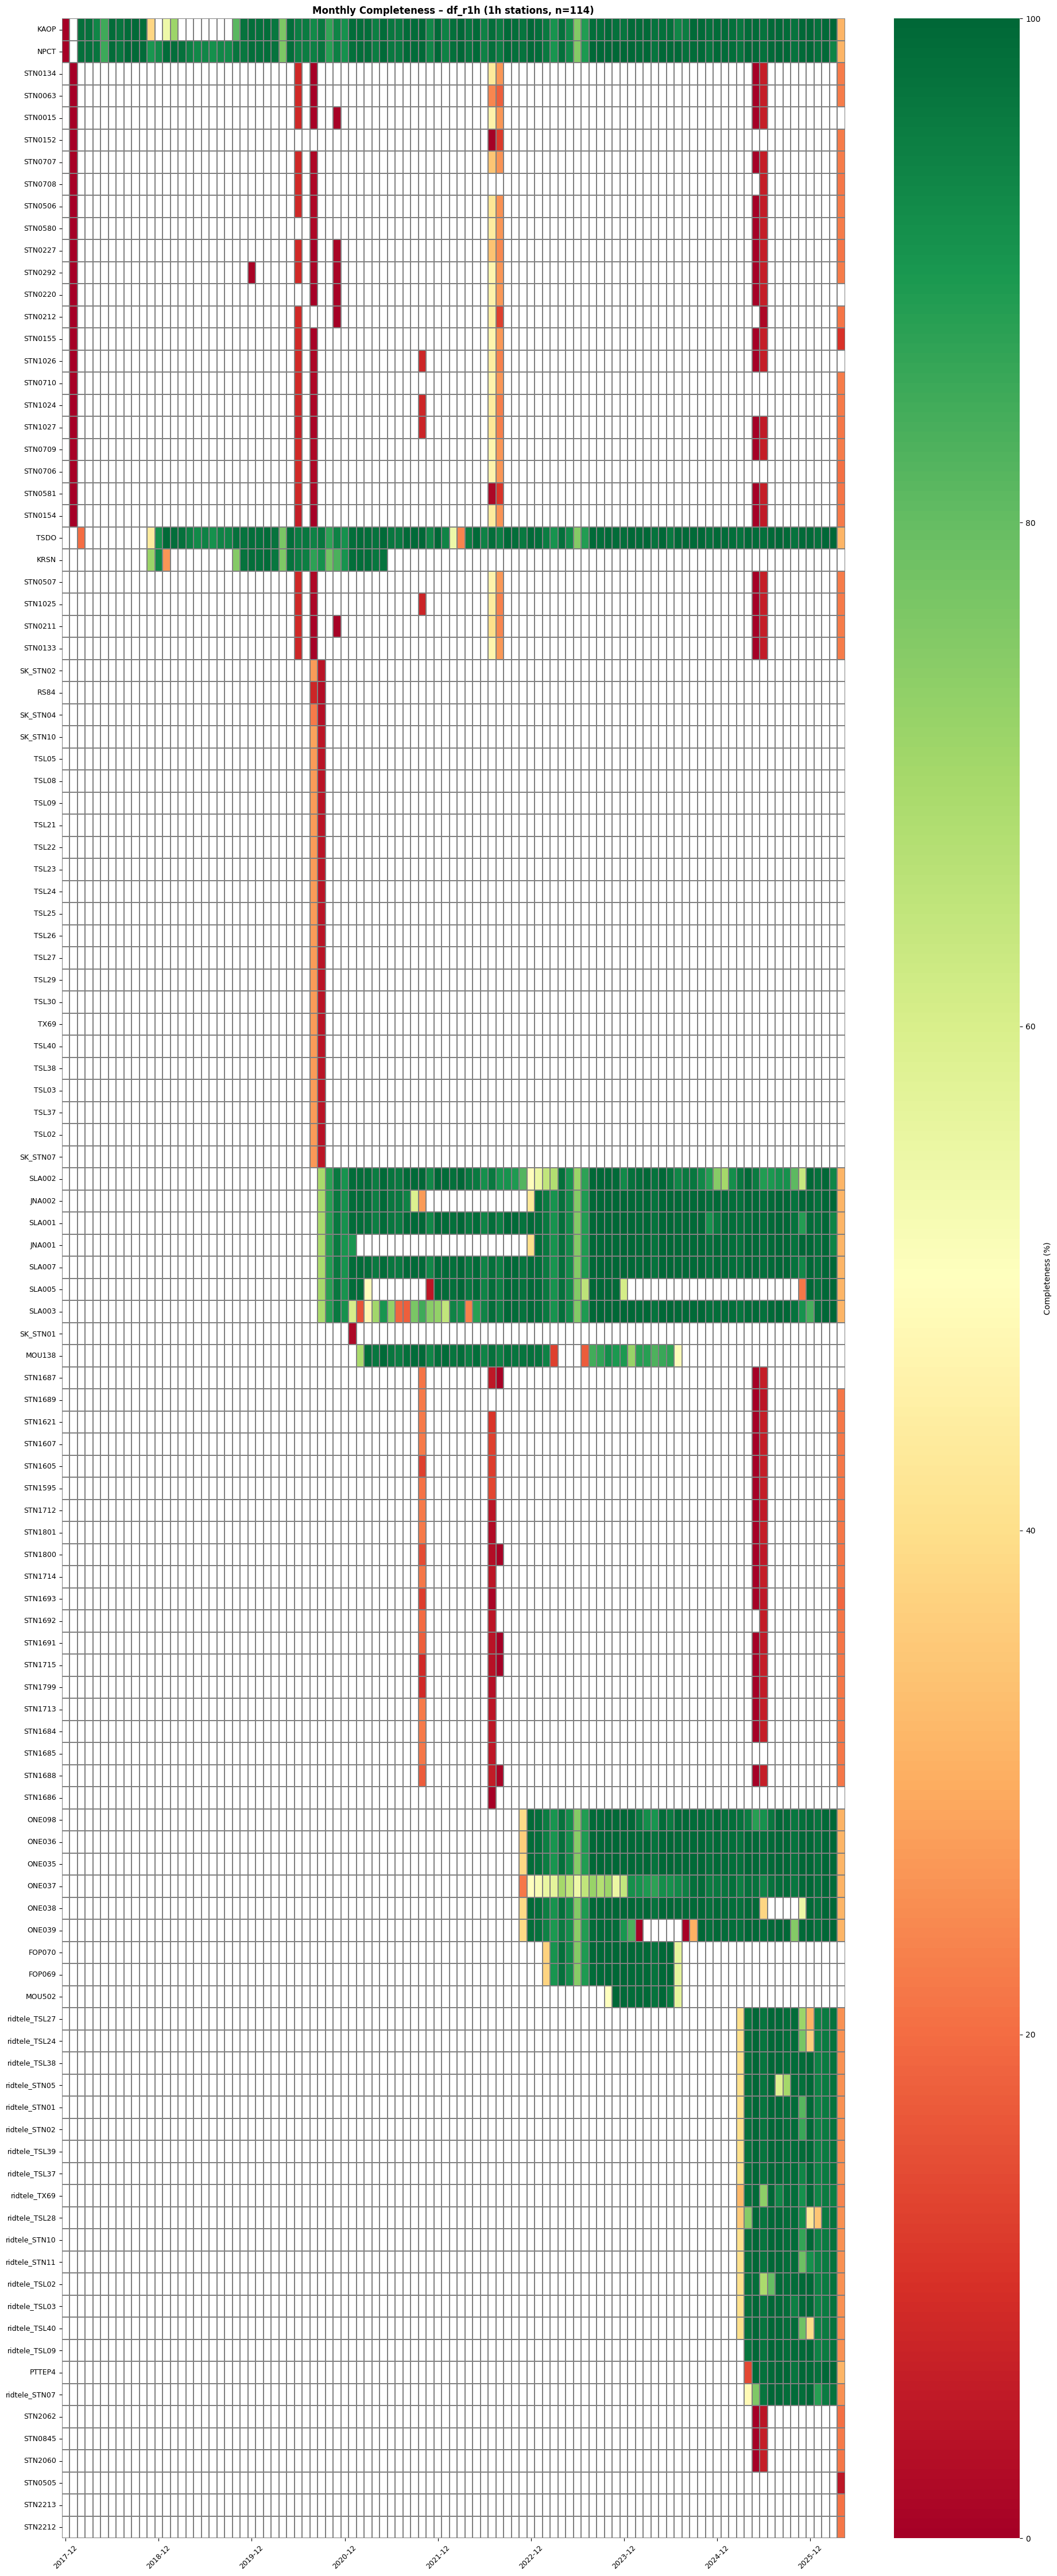

In [24]:
df_r1h['year_month'] = df_r1h['rainfall_datetime'].dt.to_period('M')
r1h_monthly = df_r1h.groupby(['tele_station_oldcode', 'year_month']).size()

r1h_period_idx = pd.period_range(
    start=df_r1h['rainfall_datetime'].min(),
    end=df_r1h['rainfall_datetime'].max(),
    freq='M'
)

r1h_full_idx = pd.MultiIndex.from_product([stn_in_df_r1h, r1h_period_idx], names=['station', 'year_month'])
r1h_monthly = r1h_monthly.reindex(r1h_full_idx, fill_value=np.nan)

r1h_expected = r1h_full_idx.get_level_values('year_month').days_in_month * 24
r1h_completeness = (r1h_monthly / r1h_expected) * 100
r1h_pivot = r1h_completeness.unstack('year_month')

r1h_first_rec = r1h_pivot.apply(lambda x: x.first_valid_index(), axis=1)
r1h_pivot = r1h_pivot.loc[r1h_first_rec.sort_values().index]

r1h_n = len(r1h_pivot)
fig_height = max(6, r1h_n * 0.5)
fig, ax = plt.subplots(figsize=(22, fig_height))
sns.heatmap(data=r1h_pivot, ax=ax,
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, linecolor='gray',
            cbar_kws={'label': 'Completeness (%)'},
            xticklabels=12)
ax.set_title(f'Monthly Completeness – df_r1h (1h stations, n={r1h_n})',
            fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, rotation=45)

#plt.savefig(OUTPUT_DIR / 'r1h_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
df.isna().sum()

tele_station_oldcode          0
station_name_th               0
rainfall_datetime             0
rainfall10m              305127
rainfall5m              3365408
rainfall30m             3365408
rainfall1h               266752
rainfall3h              3098660
tumbon_name                   0
amphoe_name                   0
province_name                 0
tmd_area_name                 0
agency                        0
dtype: int64

do all stations fall cleanly into exactly one group

In [26]:
df_grouped_resolution = df.groupby('tele_station_oldcode')[['rainfall10m', 'rainfall5m', 'rainfall30m', 'rainfall1h', 'rainfall3h']].count()
df_grouped_resolution

,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h
tele_station_oldcode,,,,,
48568,0,0,0,0,17616
48569,0,0,0,0,17628
48571,0,0,0,0,17565
48574,0,0,0,0,17580
568501,0,0,0,0,3263
568502,0,0,0,0,3257
9999911,0,0,0,0,3220
EL06,0,0,0,0,14276
EL07,0,0,0,0,19925


Some station has values more than 1 resolutions.

For example 'FOP069' station has rainfall values in 'rainfall10m' and 'rainfall1h' columns.

However, it actually is a 1h-resolution station after inspecting its 'rainfall_datetime' column.

## Monthly Completness (df)

### Determine a resolution of each station in df

In [27]:
df['interval'] = df.groupby('tele_station_oldcode')['rainfall_datetime'].diff().dt.total_seconds() / 60

interval_count = df.groupby(['tele_station_oldcode', 'interval']).size()

total_count = interval_count.groupby('tele_station_oldcode').sum()

df_resolution = interval_count.groupby(level=0).idxmax().str[1].to_frame(name='interval')

df_resolution['dominant_pct'] = round((interval_count.groupby(level=0).max() / total_count) * 100, 2)

df_resolution.index.name = 'station'

df_resolution

,interval,dominant_pct
station,,
48568,180.0,87.81
48569,180.0,87.90
48571,180.0,87.72
48574,180.0,87.78
568501,180.0,89.09
568502,180.0,88.88
9999911,180.0,88.10
EL06,60.0,89.30
EL07,60.0,94.22


In [28]:
df_resolution['dominant_pct'].min()

np.float64(45.86)

In [29]:
df_resolution.sort_values(by=['dominant_pct'], ascending=False, inplace=True)
print(df_resolution)

         interval  dominant_pct
station                        
ONE038       10.0         99.50
ONE036       10.0         99.43
PTTEP4       10.0         99.43
ONE035       10.0         99.39
SLA005       10.0         99.15
ONE039       10.0         98.98
SLA001       10.0         98.40
SLA007       10.0         97.83
JNA001       10.0         96.98
JNA002       10.0         96.74
SLA002       10.0         96.59
SLA003       10.0         96.45
TH27         60.0         94.69
EL07         60.0         94.22
TF50         60.0         93.28
TF52         60.0         93.04
TF45         60.0         92.80
ONE037       10.0         89.77
EL06         60.0         89.30
568501      180.0         89.09
568502      180.0         88.88
9999911     180.0         88.10
48569       180.0         87.90
48568       180.0         87.81
48574       180.0         87.78
48571       180.0         87.72
TF53         60.0         81.28
TH26         60.0         80.78
TF43         60.0         79.60
TSDO    

### Filter out station with less than 70% of dominant_pct

AS theirdata are not consistent enough to determine a resolution

In [30]:
df_resolution_filtered = df_resolution[df_resolution['dominant_pct'] >= 70]

Two station were dropped before plotting monthly complentess heatmaps

Number of stations for 10.0 interval: 13


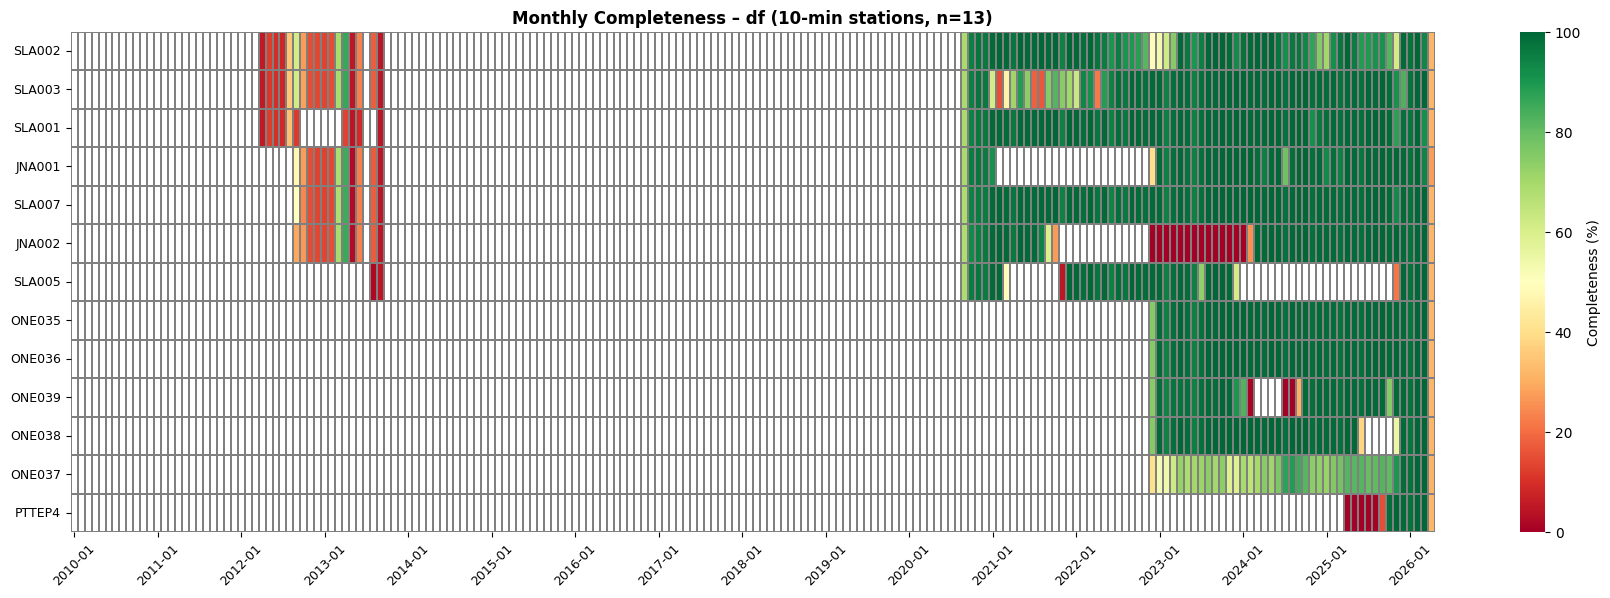

Number of stations for 60.0 interval: 20


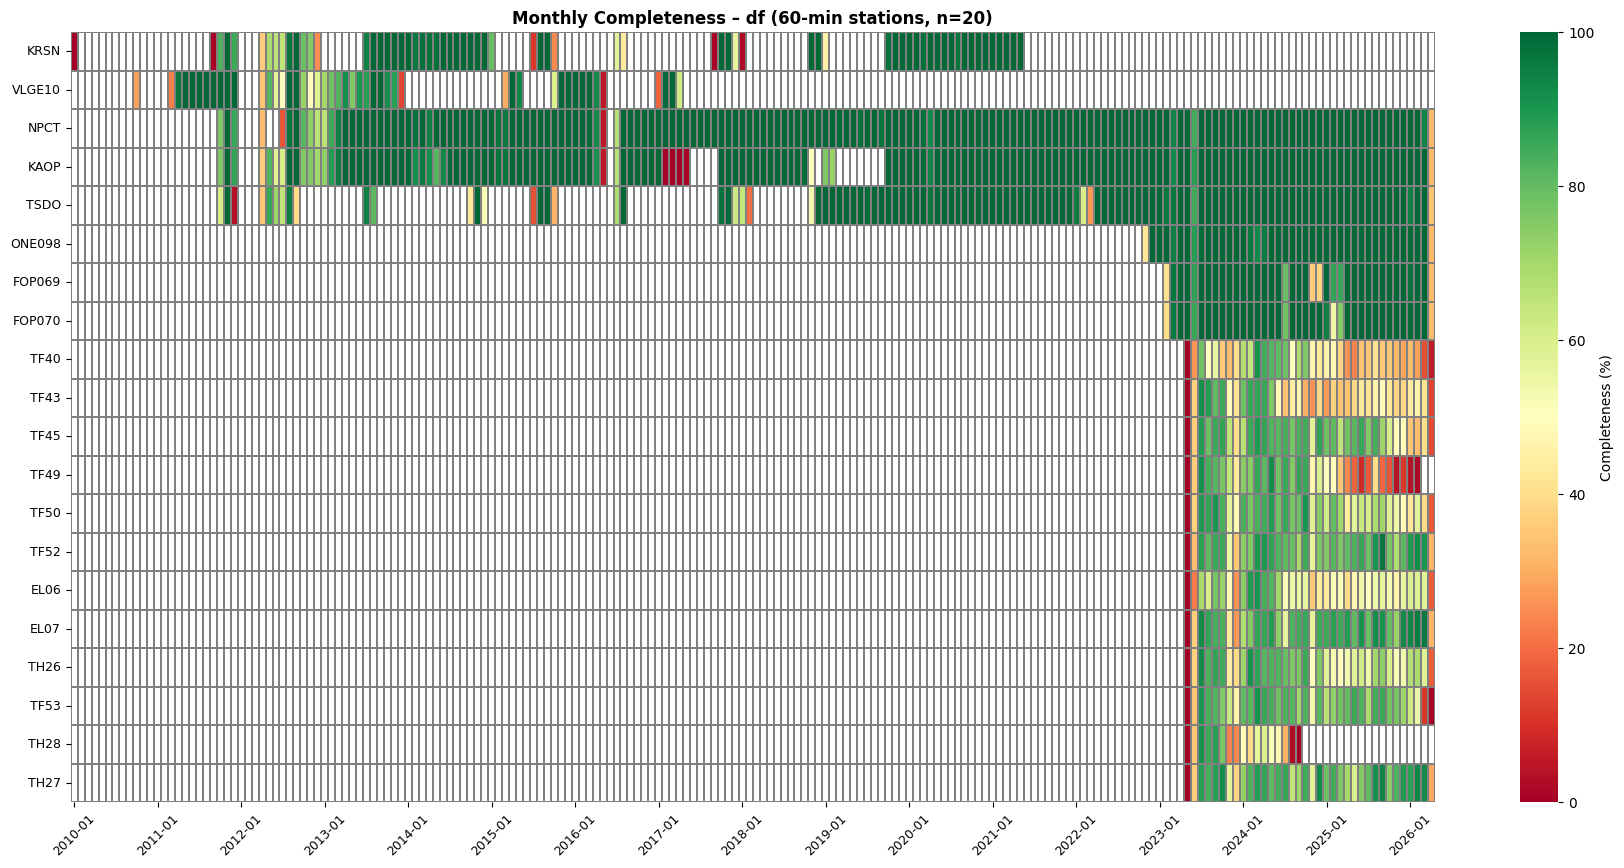

Number of stations for 180.0 interval: 7


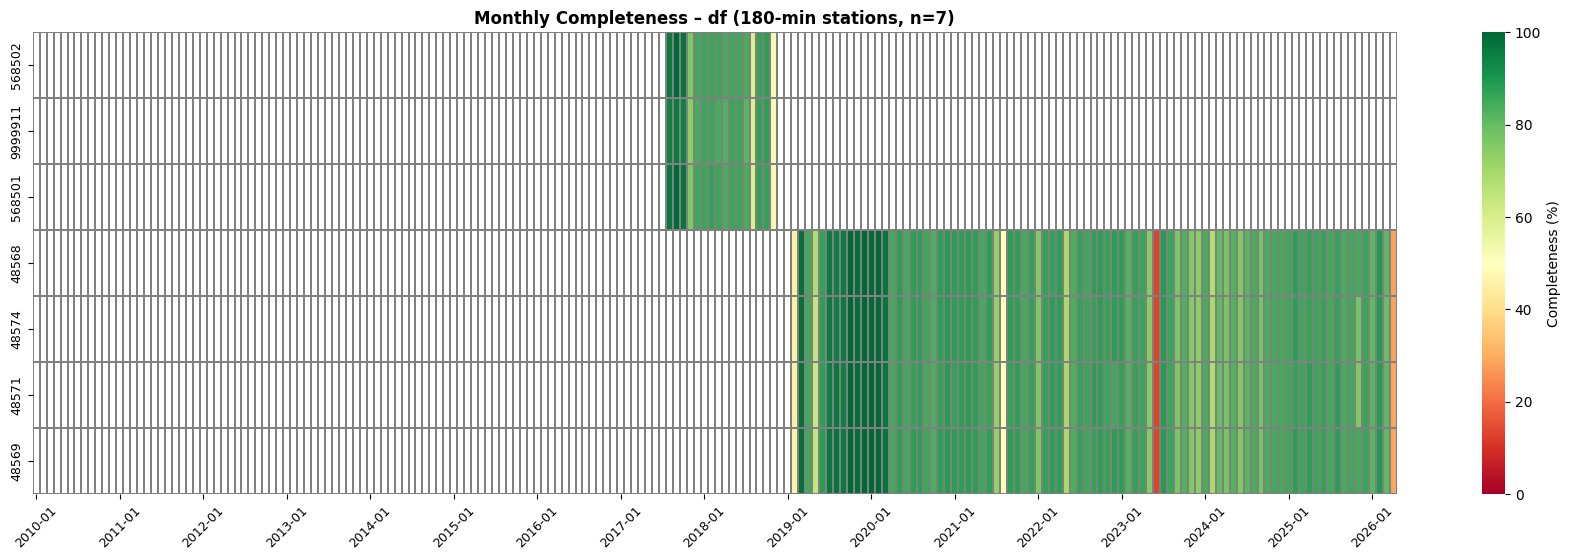

In [31]:
pivot_list = []

for interval in df_resolution_filtered['interval'].unique(): 
    
    interval_filter = df_resolution_filtered['interval'] == interval

    cadence = df[df['tele_station_oldcode'].isin(interval_filter.index[interval_filter].to_list())]
    
    print(f'Number of stations for {interval} interval: {cadence['tele_station_oldcode'].nunique()}')
    
    cadence['year_month'] = cadence['rainfall_datetime'].dt.to_period('M')
    monthly = cadence.groupby(['tele_station_oldcode', 'year_month']).size()

    period_idx = pd.period_range(
        start=df['rainfall_datetime'].min(),
        end=df['rainfall_datetime'].max(),
        freq='M'
    )

    stns = cadence['tele_station_oldcode'].unique()
    full_idx = pd.MultiIndex.from_product([stns, period_idx], names=['station', 'year_month'])
    monthly = monthly.reindex(full_idx, fill_value=np.nan)

    expected = full_idx.get_level_values('year_month').days_in_month * 24 * (60 / interval)
    completeness = (monthly / expected) * 100
    pivot = completeness.unstack('year_month')

    first_rec = pivot.apply(lambda x: x.first_valid_index(), axis=1)
    pivot = pivot.loc[first_rec.sort_values().index]
    
    pivot_list.append(pivot)
    
    n = len(pivot)
    fig_height = max(6, n * 0.5)
    fig, ax = plt.subplots(figsize=(22, fig_height))
    sns.heatmap(data=pivot, ax=ax,
                cmap='RdYlGn', vmin=0, vmax=100,
                linewidths=0.3, linecolor='gray',
                cbar_kws={'label': 'Completeness (%)'},
                xticklabels=12)
    ax.set_title(f'Monthly Completeness – df ({int(interval)}-min stations, n={n})',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    
    #plt.savefig(OUTPUT_DIR / f'df_{int(interval)}min_completeness.png', dpi=150, bbox_inches='tight')
    plt.show()

combined_df_pivot = pd.concat(pivot_list, axis=0)

# Do most stations have similar lastest date

### Lastest date of stations in the df_r1h

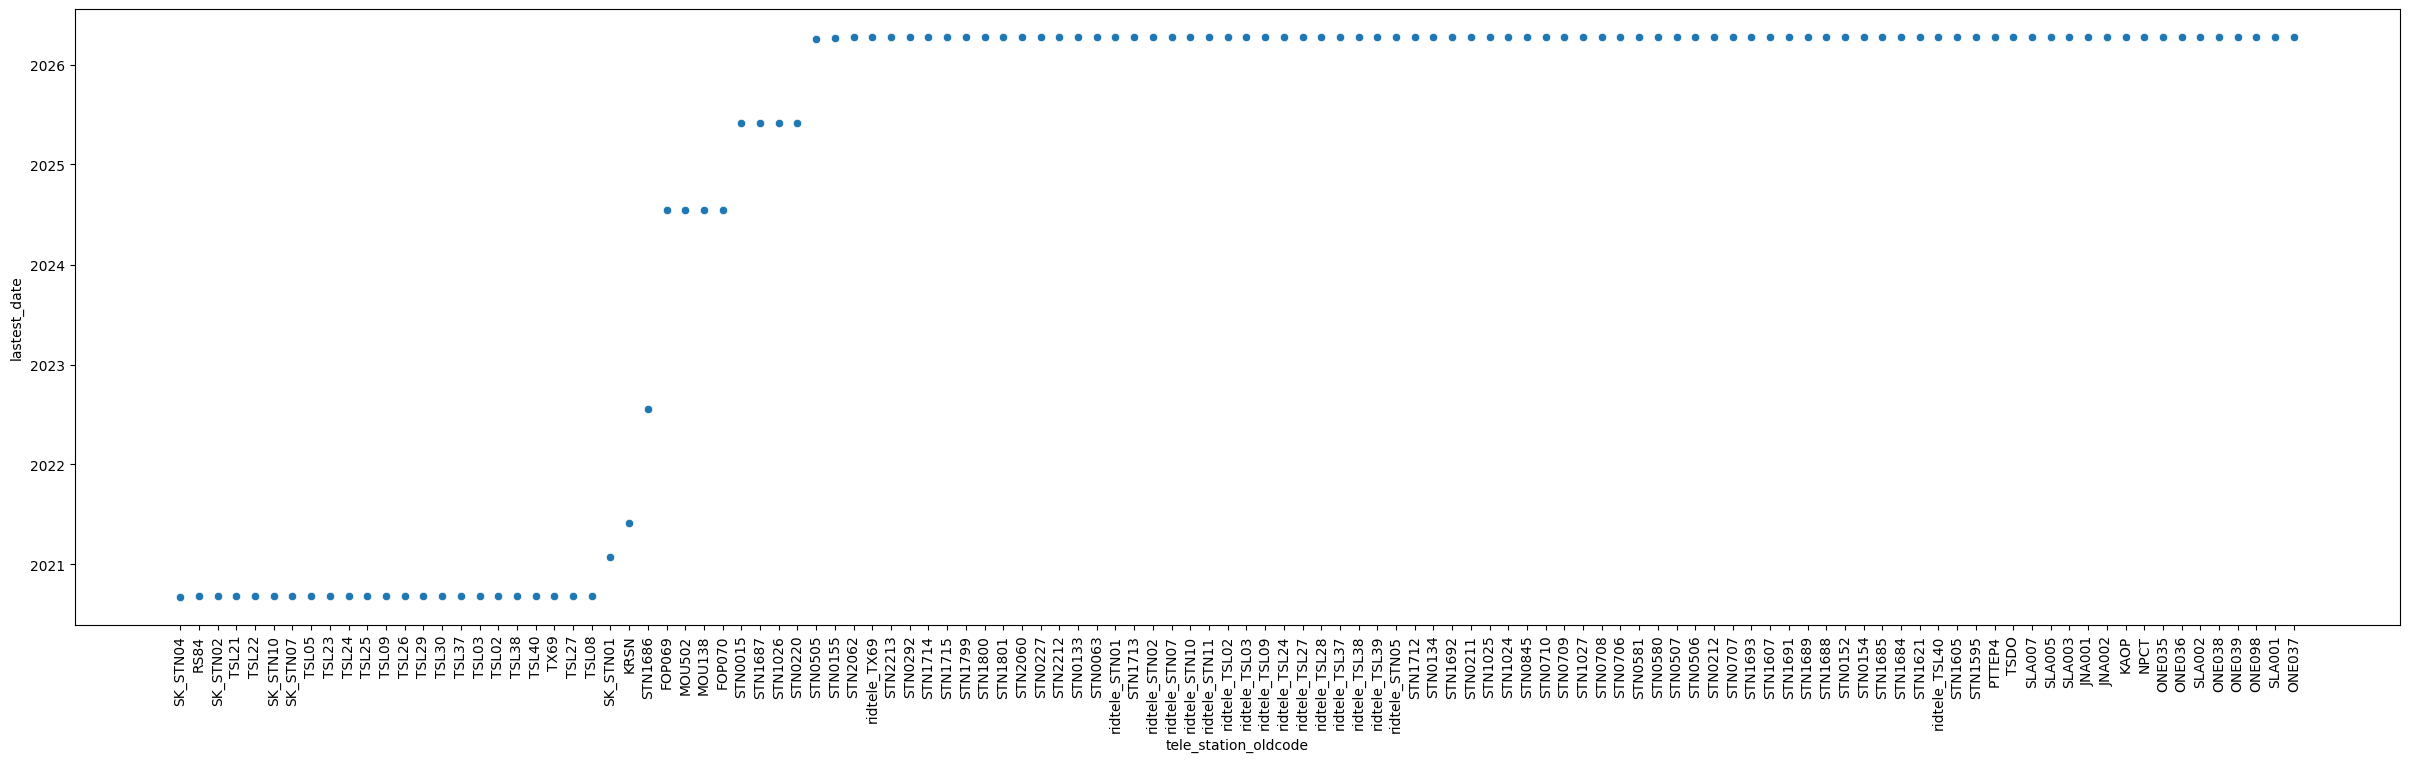

In [32]:
r1h_last_date = df_r1h.groupby('tele_station_oldcode').agg(lastest_date=('rainfall_datetime', 'max')) \
                    .sort_values('lastest_date').reset_index()

fig, ax = plt.subplots(figsize=(30, 8))

sns.scatterplot(data=r1h_last_date, x='tele_station_oldcode', y='lastest_date')
plt.xticks(rotation=90)

plt.show()

### Lastest date of stations in the df

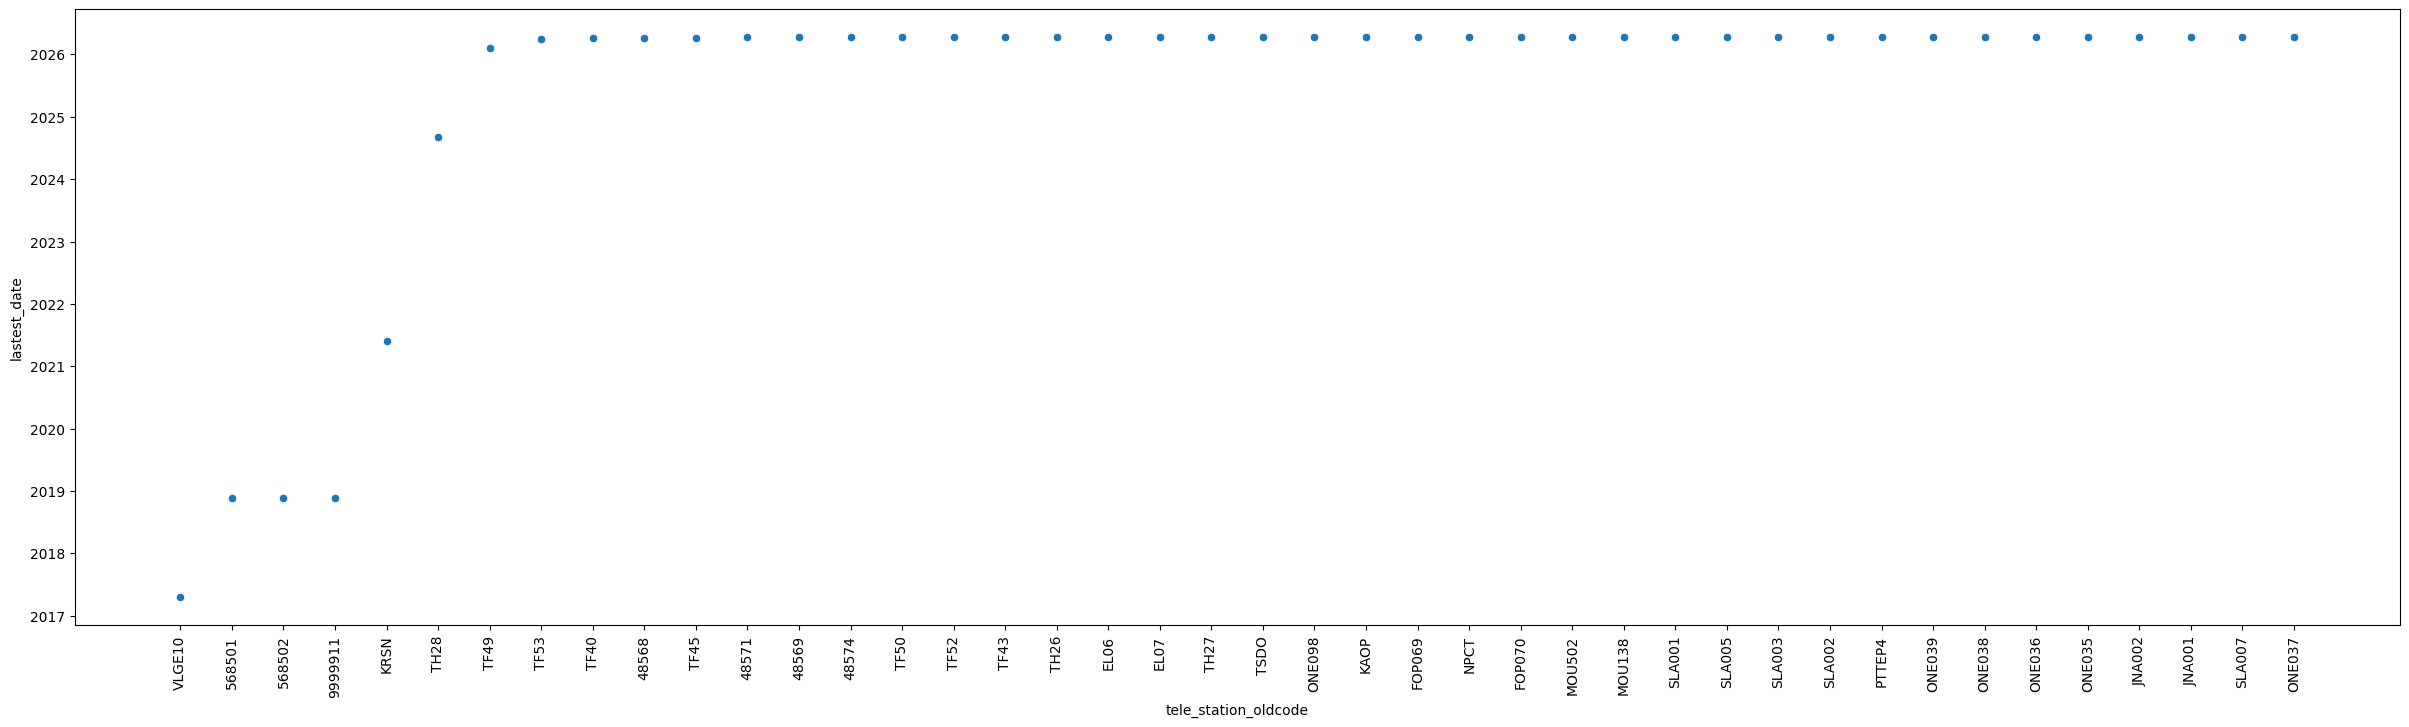

In [33]:
df_last_date = df.groupby('tele_station_oldcode').agg(lastest_date=('rainfall_datetime', 'max')) \
                    .sort_values('lastest_date').reset_index()

fig, ax = plt.subplots(figsize=(30, 8))

sns.scatterplot(data=df_last_date, x='tele_station_oldcode', y='lastest_date')
plt.xticks(rotation=90)

plt.show()

In [34]:
print(r1h_last_date.value_counts('lastest_date'))

lastest_date
2026-04-10 08:00:00    58
2020-09-07 16:00:00    21
2026-04-10 09:00:00    17
2024-07-18 12:00:00     4
2025-06-02 22:00:00     4
2026-04-10 00:00:00     2
2020-09-02 18:00:00     1
2020-09-06 10:00:00     1
2021-01-28 17:00:00     1
2021-05-31 11:00:00     1
2022-07-21 13:00:00     1
2026-04-05 02:00:00     1
2026-04-06 16:00:00     1
2026-04-10 07:00:00     1
Name: count, dtype: int64


In [35]:
print(df_last_date.value_counts('lastest_date'))

lastest_date
2026-04-10 09:50:00    13
2026-04-10 08:50:00     7
2026-04-10 09:00:00     6
2018-11-18 19:00:00     3
2026-04-10 04:00:00     3
2026-04-10 09:30:00     2
2017-04-18 08:00:00     1
2021-05-31 11:00:00     1
2024-09-06 16:00:00     1
2026-02-07 20:00:00     1
2026-04-01 12:50:00     1
2026-04-09 18:50:00     1
2026-04-10 01:00:00     1
2026-04-10 01:50:00     1
Name: count, dtype: int64


Both datasets share the **same data cutoff: 2026-04-10** — which matches the CSV filenames exactly.

The hour-level variation on that day (08:00, 09:00, 09:50, etc.) is just different stations reporting at different intervals, not meaningful divergence.

Dead station clusters are clear:
- **r1h_last_date:** 21 stations died around 2020-09-07 (a big drop), 4 at 2024-07-18, 4 at 2025-06-02
- **df_last_date:** 3 stations died in 2018, 1 in 2017, scattered others

Design decision this gives you:

Use **2026-04-10 as the global reference date** (it's the dataset cutoff, not today). Then "past 1 year" = 2025-04-10 onward.

# How many stations pass criteria of reliable stations

### Summary DataFrame (df_r1h)

In [36]:
r1h_summary = df_r1h.groupby('tele_station_oldcode')['rainfall_datetime'].agg(['min', 'max'])
r1h_summary['span_yr'] = r1h_summary['max'] - r1h_summary['min']
r1h_summary['span_yr'] = r1h_summary['span_yr'] / pd.Timedelta(365.25, 'D')
r1h_summary.rename(columns={'min': 'start_date','max': 'lastest_date'}, inplace=True)
r1h_summary['lifetime_pct'] = r1h_pivot.mean(axis=1)
r1h_summary['recent_pct'] = r1h_pivot.iloc[:,-13:-1].mean(axis=1)       # compute stations' completeness over the past 12 months

r1h_summary

,start_date,lastest_date,span_yr,lifetime_pct,recent_pct
tele_station_oldcode,,,,,
FOP069,2023-02-18 09:00:00,2024-07-18 12:00:00,1.413073,90.719998,NaN
FOP070,2023-02-18 14:00:00,2024-07-18 12:00:00,1.412503,90.847311,NaN
JNA001,2020-09-09 16:00:00,2026-04-10 09:00:00,5.581679,93.850620,98.804804
JNA002,2020-09-09 16:00:00,2026-04-10 09:00:00,5.581679,92.788625,99.320783
KAOP,2017-12-31 23:00:00,2026-04-10 09:00:00,8.272188,93.455924,99.021191
...,...,...,...,...,...
ridtele_TSL37,2025-03-18 14:00:00,2026-04-10 08:00:00,1.061602,88.470302,97.703106
ridtele_TSL38,2025-03-18 14:00:00,2026-04-10 08:00:00,1.061602,88.867127,98.177643
ridtele_TSL39,2025-03-18 14:00:00,2026-04-10 08:00:00,1.061602,88.867127,98.166069


## Filtering for reliable stations (df_r1h)

### Create the past 1 year lifetime percentage column

In [37]:
r1h_after_recent = r1h_summary[(r1h_summary['recent_pct'] >= 70)]
r1h_after_completeness = r1h_after_recent[(r1h_after_recent['lifetime_pct'] >= 70)]
r1h_after_span = r1h_after_completeness[((r1h_after_completeness['span_yr'] >= 3))]
r1h_summary_qual = r1h_after_span[r1h_after_span.index.isin(df_meta2['tele_station_oldcode'])]

In [38]:
r1h_labels = ['Has lat/lon in metadata', 
            'Record spans ≥ 3 years', 
            'Avg. monthly completeness ≥ 70%\n(full record)',
            'Avg. monthly completeness ≥ 70%\n(past 12 months)',
             'All stations in dataset']


r1h_counts = [len(r1h_summary_qual),
          len(r1h_after_span),
          len(r1h_after_completeness),
          len(r1h_after_recent),
          df_r1h['tele_station_oldcode'].nunique()]


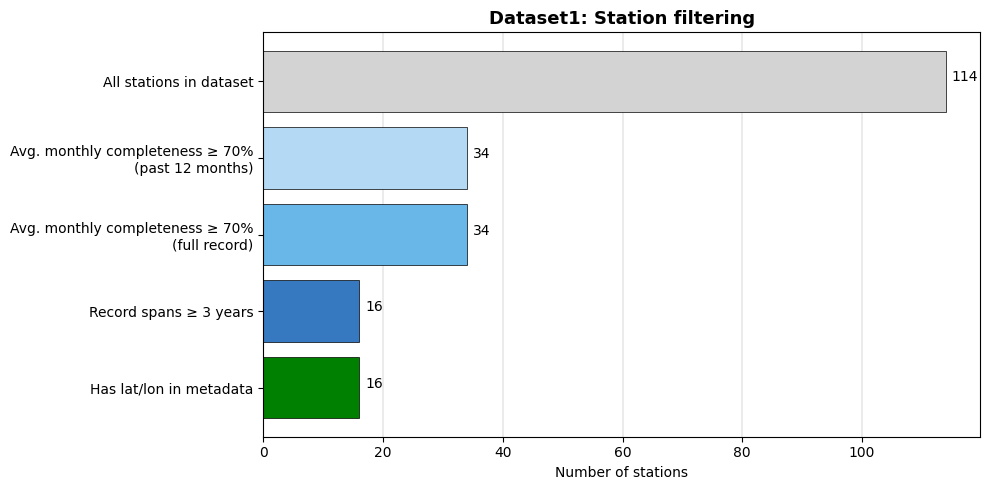

In [39]:
colors = ['green', "#3679c0", "#69b6e9", "#b3d9f5",'lightgrey']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(r1h_labels, r1h_counts, color=colors, edgecolor='black', linewidth=0.5)        # ax.barh plots from bottom to top

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(width + 1, y, str(width))

ax.set_xticks(range(0, max(r1h_counts)+1, 20))
ax.xaxis.grid(True, linewidth=0.35)
    
ax.set_title('Dataset1: Station filtering', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of stations')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Summary DataFrame (df)

In [40]:
df_summary = df.groupby('tele_station_oldcode')['rainfall_datetime'].agg(['min', 'max'])
df_summary['span_yr'] = df_summary['max'] - df_summary['min']
df_summary['span_yr'] = df_summary['span_yr'] / pd.Timedelta(365.25, 'D')
df_summary.rename(columns={'min': 'start_date','max': 'lastest_date'}, inplace=True)
df_summary['lifetime_pct'] = combined_df_pivot.mean(axis=1)
df_summary['recent_pct'] = combined_df_pivot.iloc[:,-13:-1].mean(axis=1)       # compute stations' completeness over the past 12 months

df_summary


,start_date,lastest_date,span_yr,lifetime_pct,recent_pct
tele_station_oldcode,,,,,
48568,2019-02-14 13:00:00,2026-04-10 01:00:00,7.149897,83.169997,85.310100
48569,2019-02-14 13:00:00,2026-04-10 04:00:00,7.150240,83.227997,85.378424
48571,2019-02-14 13:00:00,2026-04-10 04:00:00,7.150240,82.927818,84.573733
48574,2019-02-14 13:00:00,2026-04-10 04:00:00,7.150240,83.000330,84.344358
568501,2017-08-02 01:00:00,2018-11-18 19:00:00,1.297057,83.737219,NaN
568502,2017-08-02 01:00:00,2018-11-18 19:00:00,1.297057,83.577069,NaN
9999911,2017-08-02 01:00:00,2018-11-18 19:00:00,1.297057,82.632008,NaN
EL06,2023-05-29 16:40:00,2026-04-10 08:50:00,2.865636,54.299801,52.532935
EL07,2023-05-29 16:40:00,2026-04-10 08:50:00,2.865636,75.773310,87.762177


### Filtering for reliable stations (df)

In [41]:
after_resolution = df_summary[df_summary.index.isin(df_resolution_filtered.index)]
after_recent = after_resolution[(after_resolution['recent_pct'] >= 70)]
after_completeness = after_recent[(after_recent['lifetime_pct'] >= 70)]
after_span = after_completeness[((after_completeness['span_yr'] >= 3))]
df_summary_qual = after_span[after_span.index.isin(df_meta2['tele_station_oldcode'])]

In [42]:
labels = ['Has lat/lon in metadata', 
          'Record spans ≥ 3 years', 
          'Avg. monthly completeness ≥ 70%\n(full record)', 
          'Avg. monthly completeness ≥ 70%\n(past 12 months)',
          'Consistent reporting interval\n(dominant_pct ≥ 70%)', 
          'After removing incomplete record\n(NaNs)', 
          'All stations in dataset']

counts = [len(df_summary_qual),
          len(after_span),
          len(after_completeness),
          len(after_recent),
          len(df_resolution_filtered),
          df['tele_station_oldcode'].nunique(),
          df_raw['tele_station_oldcode'].nunique()]

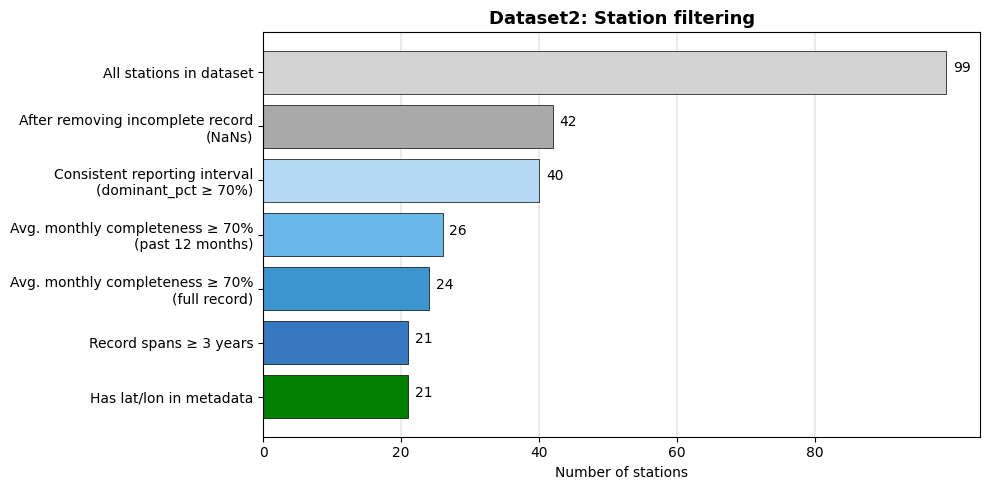

In [43]:
colors = ['green', "#3679c0", "#3c95cf", "#69b6e9", "#b3d9f5", 'darkgrey', 'lightgrey']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(labels, counts, color=colors, edgecolor='black', linewidth=0.5)        # ax.barh plots from bottom to top

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(width + 1, y, str(width))

ax.set_xticks(range(0, max(counts)+1, 20))
ax.xaxis.grid(True, linewidth=0.35)
    
ax.set_title('Dataset2: Station filtering', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of stations')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Qualified Station Overlap

In [44]:
r1h_summary_qual

,start_date,lastest_date,span_yr,lifetime_pct,recent_pct
tele_station_oldcode,,,,,
JNA001,2020-09-09 16:00:00,2026-04-10 09:00:00,5.581679,93.850620,98.804804
JNA002,2020-09-09 16:00:00,2026-04-10 09:00:00,5.581679,92.788625,99.320783
KAOP,2017-12-31 23:00:00,2026-04-10 09:00:00,8.272188,93.455924,99.021191
NPCT,2017-12-31 23:00:00,2026-04-10 09:00:00,8.272188,95.139806,98.677702
ONE035,2022-11-18 18:00:00,2026-04-10 09:00:00,3.391170,94.885457,99.252005
ONE036,2022-11-19 12:00:00,2026-04-10 09:00:00,3.389117,94.824684,99.286808
ONE037,2022-11-18 19:00:00,2026-04-10 09:00:00,3.391056,81.848707,98.090571
ONE038,2022-11-18 17:00:00,2026-04-10 09:00:00,3.391285,91.721181,86.104711
ONE039,2022-11-18 17:00:00,2026-04-10 09:00:00,3.391285,85.559706,97.449517


In [45]:
stn_overlap_qual = set(r1h_summary_qual.index) & set(df_summary_qual.index)      # '&' is equivalent to set1.intersection(set2)

print(f'Number of overlapped qualified stations: {len(stn_overlap_qual)}')

Number of overlapped qualified stations: 15


# Lifetime percentages and span years of overlapped stations from df and df_r1h

In [46]:
r1h_overlap = r1h_summary.loc[list(stn_overlap_qual), ['span_yr', 'lifetime_pct']]

df_overlap = df_summary.loc[list(stn_overlap_qual), ['span_yr', 'lifetime_pct']]

overlap = r1h_overlap.merge(df_overlap, on='tele_station_oldcode', suffixes=('_r1h', '_df'))

overlap = pd.merge(left=overlap, right=df_resolution, left_index=True, right_index=True)

overlap

,span_yr_r1h,lifetime_pct_r1h,span_yr_df,lifetime_pct_df,interval,dominant_pct
tele_station_oldcode,,,,,,
KAOP,8.272188,93.455924,14.492927,106.365083,60.0,76.51
ONE036,3.389117,94.824684,3.336680,96.692125,10.0,99.43
ONE098,3.391285,93.550848,3.391285,112.402179,60.0,75.02
SLA003,5.581679,87.016530,14.011750,75.040508,10.0,96.45
ONE039,3.391285,85.559706,3.336680,84.935936,10.0,98.98
ONE035,3.391170,94.885457,3.336680,96.650851,10.0,99.39
SLA001,5.581679,95.857910,14.011750,85.798273,10.0,98.40
NPCT,8.272188,95.139806,14.493269,112.091295,60.0,76.12
SLA005,5.581679,87.257671,12.677713,84.489345,10.0,99.15


The 11 stations with interval = 10.0 automatically go to df — 10-min resolution is strictly better than 1h for I-D analysis, no comparison needed. 

Only the 4 with interval = 60.0 (KAOP, ONE098, TSDO, NPCT), need a decision since both datasets give the same resolution for them.

## Compare df vs df_r1h coverage for the 4 overlap stations with 60-min interval in df 

In [47]:
overlap_60m = overlap[overlap['interval'] == 60]

In [64]:
r1h_annual_completeness = r1h_pivot[r1h_pivot.index.isin(overlap_60m.index)] \
                            .T.groupby(r1h_pivot.columns.year).mean() \
                            .T.round(2).sort_index()
r1h_annual_completeness

year_month,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station,,,,,,,,,,
KAOP,0.13,90.56,80.61,93.33,97.82,97.74,94.33,98.10,98.72,82.20
NPCT,0.13,95.97,95.58,93.79,97.89,97.70,95.04,98.98,98.97,80.69
ONE098,NaN,NaN,NaN,NaN,NaN,69.32,94.71,97.28,96.61,81.82
TSDO,NaN,51.79,95.95,93.87,98.20,87.41,94.59,98.99,98.95,82.24


In [62]:
df_annual_completeness = combined_df_pivot[combined_df_pivot.index.isin(overlap_60m.index)] \
                            .T.groupby(combined_df_pivot.columns.year).mean() \
                            .T.round(2).sort_index()
df_annual_completeness

year_month,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
station,,,,,,,,,,,,,,,,,
KAOP,NaN,89.16,76.08,105.66,109.05,113.24,102.48,57.31,97.36,99.77,114.72,117.17,125.76,118.12,115.19,119.94,84.51
NPCT,NaN,89.35,67.77,105.80,112.25,107.59,100.19,119.19,114.07,111.25,119.16,121.31,121.14,115.64,125.60,124.41,82.48
ONE098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.59,115.01,115.03,118.26,83.03
TSDO,NaN,55.54,65.21,87.70,70.29,70.54,86.96,107.52,62.41,107.85,113.18,115.65,105.75,110.47,113.31,115.38,83.36


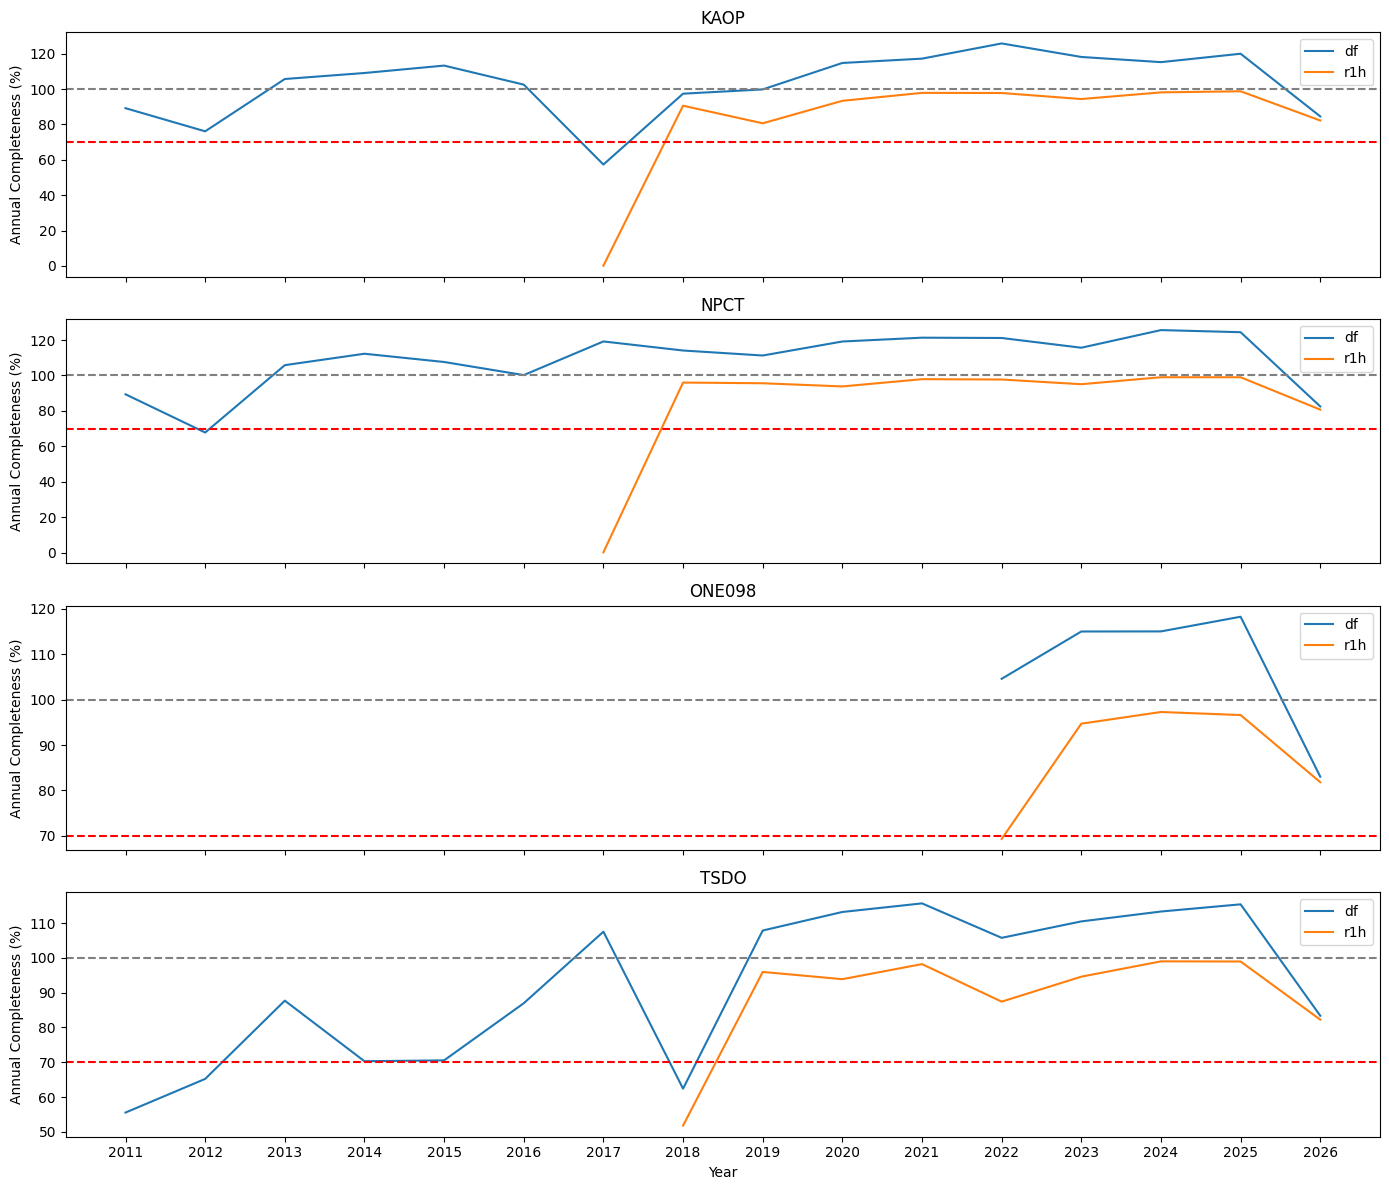

In [91]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for i, station in enumerate(r1h_annual_completeness.index):
    
    df_annual_completeness.loc[station].plot(ax=axes[i], label='df')
    r1h_annual_completeness.loc[station].plot(ax=axes[i], label='r1h')
    
    axes[i].axhline(70, linestyle='--', color='red')
    axes[i].axhline(100, linestyle='--', color='gray')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Annual Completeness (%)')
    axes[i].set_title(station)
    axes[i].legend()
    
    # tells matplotlib to place a tick mark every 1 unit on the x-axis — since your x-axis is years, that means every year gets a tick.
    axes[i].xaxis.set_major_locator(plt.MultipleLocator(1))     
    
plt.savefig(OUTPUT_DIR / f'overlap_60m_annual_completeness.png', dpi=150, bbox_inches='tight')
fig.tight_layout()

    

# rainfall1h column verification

In [54]:
inspect_df_idx = 6

kaop = df[df['tele_station_oldcode'] == 'KAOP'][['rainfall_datetime', 'rainfall10m', 'rainfall1h']].copy()
kaop = kaop.sort_values('rainfall_datetime').reset_index(drop=True)

rainy_indices = kaop[kaop['rainfall10m'] > 0].index

# Show third rainy stretch
sample_rain_idx = rainy_indices[inspect_df_idx]
window = kaop.iloc[max(0, sample_rain_idx - 6) : sample_rain_idx + 20]
print(window.to_string())


      rainfall_datetime  rainfall10m  rainfall1h
93  2011-10-17 23:00:00          0.0         0.4
94  2011-10-17 23:10:00          0.2         0.2
95  2011-10-18 00:00:00          0.0         0.2
96  2011-10-18 00:50:00          0.6         0.6
97  2011-10-18 01:00:00          1.2         1.8
98  2011-10-18 01:10:00          0.2         0.2
99  2011-10-18 01:20:00          3.0         3.2
100 2011-10-18 01:30:00          4.6         7.8
101 2011-10-18 01:40:00          0.2         8.0
102 2011-10-18 01:50:00          0.2         8.2
103 2011-10-18 02:00:00          0.0         8.2
104 2011-10-18 03:00:00          0.0         0.0
105 2011-10-18 04:00:00          0.0         0.0
106 2011-10-18 04:40:00          0.4         0.4
107 2011-10-18 04:50:00          2.0         2.4
108 2011-10-18 05:00:00          0.0         2.4
109 2011-10-18 06:00:00          0.0         0.0
110 2011-10-18 07:00:00          0.0         0.0
111 2011-10-18 08:00:00          0.0         0.0
112 2011-10-18 09:00

**Finding:** rainfall1h of df is a running total that resets every clock hour 

  rainfall1h accumulates rainfall10m values row by row within each clock hour. The xx:00 row always shows the completed total for that hour, then the next row starts
  fresh from zero.

  Tracing the data above (inspect_df_idx = 6):
  - 22:xx hour: closes at 23:00 with total 0.4mm ✓
  - 23:xx hour: 23:10 (0.2) → closes at 00:00 with total 0.2mm ✓
  - 00:xx hour: 00:50 (0.6) → closes at 01:00 with total 1.8mm (0.6 + 1.2 at 01:00) ✓
  - 01:xx hour: 01:10 (0.2) → 01:20 (3.2) → 01:30 (7.8) → 01:40 (8.0) → 01:50 (8.2) → closes at 02:00 with total 8.2mm ✓
  - 02:xx–03:xx hours: both 0.0mm — no rain ✓
  - 04:xx hour: 04:40 (0.4) → 04:50 (2.4) → closes at 05:00 with total 2.4mm ✓
  - 11:xx hour: closes at 12:00 with 6.6mm — despite no 11:xx rows visible, the total is preserved ✓

  Notable: Row 114 shows 6.6mm at 12:00 with no 11:xx rows in the data — the hourly total is captured even when individual 10-min records are missing.

  Implication: For I-D analysis, use rainfall10m with time-based rolling windows to compute rainfall at any duration. The rainfall1h column is useful for understanding
  the data but should not be used as a substitute for custom duration windows.

In [55]:
stn = 'ONE038'
inspect_idx = 100

hourly_df = (df[df['tele_station_oldcode'] == stn]
        .set_index('rainfall_datetime')['rainfall10m']
        .resample('1h').sum())

hourly_r1h = (df_r1h[df_r1h['tele_station_oldcode'] == stn]
        .set_index('rainfall_datetime')['rainfall1h'])

merged = (pd.merge(hourly_df, hourly_r1h, left_index=True, right_index=True)
        .reset_index())
merged.columns = ['rainfall_datetime', 'r10m_resampled_1h', 'rainfall1h_r1h']

rainy_idx = merged[merged['r10m_resampled_1h'] > 0].index
ref_idx = rainy_idx[inspect_idx]
window = merged.iloc[max(0, ref_idx - 5) : ref_idx + 20]

print(window.to_string())

      rainfall_datetime  r10m_resampled_1h  rainfall1h_r1h
250 2022-12-19 04:00:00               32.0            23.4
251 2022-12-19 05:00:00                2.8            27.0
252 2022-12-19 06:00:00               26.0             3.2
253 2022-12-19 07:00:00                8.6            24.8
254 2022-12-19 08:00:00               13.0             9.4
255 2022-12-19 09:00:00               21.0            12.8
256 2022-12-19 10:00:00                6.6            22.0
257 2022-12-19 11:00:00                3.0             5.2
258 2022-12-19 12:00:00                0.0             2.2
259 2022-12-19 13:00:00                0.0             0.0
260 2022-12-19 14:00:00                0.0             0.0
261 2022-12-19 15:00:00                0.0             0.0
262 2022-12-19 16:00:00                0.0             0.0
263 2022-12-19 17:00:00                0.0             0.0
264 2022-12-19 18:00:00                0.0             0.0
265 2022-12-19 19:00:00                0.0             0

In [56]:
hourly_r1h_shifted = (df_r1h[df_r1h['tele_station_oldcode'] == stn]
                .set_index('rainfall_datetime')['rainfall1h']
                .shift(-1, freq='1h'))

merged_shifted = (pd.merge(hourly_df, hourly_r1h_shifted, left_index=True, right_index=True)
                .reset_index())
merged_shifted.columns = ['rainfall_datetime', 'r10m_resampled_1h', 'rainfall1h_r1h_shifted']

rainy_idx_shifted = merged_shifted[merged_shifted['r10m_resampled_1h'] > 0].index
ref_idx_shifted = rainy_idx_shifted[inspect_idx]
window_shifted = merged_shifted.iloc[max(0, ref_idx_shifted - 5) : ref_idx_shifted + 20]

print(window_shifted.to_string())

      rainfall_datetime  r10m_resampled_1h  rainfall1h_r1h_shifted
250 2022-12-19 04:00:00               32.0                    27.0
251 2022-12-19 05:00:00                2.8                     3.2
252 2022-12-19 06:00:00               26.0                    24.8
253 2022-12-19 07:00:00                8.6                     9.4
254 2022-12-19 08:00:00               13.0                    12.8
255 2022-12-19 09:00:00               21.0                    22.0
256 2022-12-19 10:00:00                6.6                     5.2
257 2022-12-19 11:00:00                3.0                     2.2
258 2022-12-19 12:00:00                0.0                     0.0
259 2022-12-19 13:00:00                0.0                     0.0
260 2022-12-19 14:00:00                0.0                     0.0
261 2022-12-19 15:00:00                0.0                     0.0
262 2022-12-19 16:00:00                0.0                     0.0
263 2022-12-19 17:00:00                0.0                    

In [ ]:
stn_df_only = set(df_summary_qual.index) - set(overlap.index)
stn_r1h_only = set(r1h_summary_qual.index) - set(overlap.index)
stn_overlap_only = set(overlap.index) -  {'ONE098'}

dict_stn_df = dict.fromkeys(stn_df_only, 'df')
dict_stn_r1h = dict.fromkeys(stn_r1h_only, 'r1h')
dict_stn_overlap = dict.fromkeys(stn_overlap_only, 'df')
dict_ONE098 = {'ONE098': 'r1h'}     # ONE098 better use r1h as a rainfall data (based on annual completeness comparison between df and r1h)

merge_dict = {**dict_stn_df, **dict_stn_r1h, **dict_stn_overlap, **dict_ONE098}

stn_source = pd.DataFrame.from_dict(merge_dict, orient='index', columns=['source'])

stn_source

,source
48571,df
48569,df
48568,df
FOP070,df
48574,df
FOP069,df
JNA002,r1h
KAOP,df
ONE036,df
SLA003,df
